# Lab 1 — Perception Audit and Five Encodings
### SDA-DSC-112 · Module 1 · Perception Science and Visual Encoding · **50 minutes**

| | |
|---|---|
| **Objective** | Encode one Tayseer metric five different ways, rank the encodings by decoding accuracy for a stated task, and run a pre-attentive audit on a deliberately bad dashboard |
| **Dataset** | `data/core/tayseer_services.csv` · `data/dimensions/dim_regions.csv` · `data/instructional/encoding_accuracy_ranking.csv` |
| **Output** | Five encodings, a ranked justification, a written audit, one corrected chart with a lie factor of 1.0 |

| Task | Minutes |
|---|---|
| 1 · Load the golden thread and state the task | 5 |
| 2 · Encode the same series five ways | 15 |
| 3 · Rank your five encodings against Cleveland–McGill | 10 |
| 4 · Perception audit of the bad dashboard | 10 |
| 5 · One corrected chart, exactly one pre-attentive pop | 5 |
| 6 · Lie factor and the benchmark table | 5 |

### Setup

`tayseer_viz.py` sits next to this notebook. It holds the course theme (Okabe–Ito,
colour-blind safe), the correctly-implemented **non-additive measures**, and
`sorted_bar()` — the chart function with the five design principles baked in.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tayseer_viz as tv
tv.apply_theme()

df = tv.load_facts()
print(f"{len(df):,} rows x {df.shape[1]} columns")
print(df.columns.tolist())

28,080 rows x 12 columns
['month', 'region', 'service_category', 'channel', 'transactions', 'unique_users', 'digital_adoption_pct', 'avg_completion_min', 'cost_per_txn_sar', 'csat', 'sla_met_pct', 'complaints']


---
## Task 1 — Load the golden thread and state the task *(5 min)*

Load `tayseer_services.csv` and compute **latest-month `digital_adoption_pct` by region**.

State the analytical task in one sentence before you draw anything:

> *"Let a Deputy Minister rank the 13 regions and spot the laggards."*

**The trap you must not fall into.** `digital_adoption_pct` is a **non-additive**
measure recorded at the `month × region × service_category` grain and repeated
across that segment's four channel rows. `AVERAGE()`-ing it gives the wrong number.
Recompute it from `unique_users`, exactly as `kpi_targets.csv` KPI-01 specifies:

```
SUM(digital_adoption_pct / 100 * unique_users) / SUM(unique_users) * 100
```

In [2]:
latest = df[df.month == df.month.max()]
print("Latest month:", latest.month.iloc[0].date())

# The correct, user-weighted national number (KPI-01) ...
national_weighted = tv.adoption(latest)
# ... and the averages-of-averages bug this course exists to prevent.
national_naive = latest.digital_adoption_pct.mean()

print(f"weighted national adoption : {national_weighted:.1f}%   <- correct")
print(f"naive AVERAGE of the column: {national_naive:.1f}%   <- the bug")
print(f"error                      : {national_weighted - national_naive:+.2f} pp")

region_adoption = (tv.by(latest, "region", "digital_adoption_pct")
                     .rename(columns={"digital_adoption_pct": "adoption_pct"})
                     .sort_values("adoption_pct", ascending=False)
                     .reset_index(drop=True))

assert region_adoption.shape == (13, 2)
assert round(national_weighted, 1) == 63.8, national_weighted
assert round(national_naive, 1) == 61.2, national_naive
region_adoption

Latest month: 2026-06-01
weighted national adoption : 63.8%   <- correct
naive AVERAGE of the column: 61.2%   <- the bug
error                      : +2.64 pp


,region,adoption_pct
0,Riyadh,67.753866
1,Eastern Province,67.364929
2,Qassim,65.824942
3,Tabuk,65.094457
4,Hail,64.972158
5,Al-Jouf,63.224481
6,Makkah,63.093663
7,Madinah,62.063507
8,Northern Borders,61.671397
9,Asir,60.150779


**Instructor commentary.** That 2.6-point gap is not a rounding artefact — it is the
single most expensive bug in enterprise BI. It appears because each region contributes
a different number of users, and an unweighted average silently gives Al-Baha (a small
region) the same vote as Riyadh. The direction matters too: the naive number is
*pessimistic* here, so an analyst who ships it under-reports national progress by
2.6 points in a Vision 2030 briefing. Print both numbers in front of the room.

---
## Task 2 — Encode the same series five ways *(15 min)*

Same thirteen numbers, five encodings:

| | Encoding | Cleveland–McGill channel | Rank |
|---|---|---|---|
| (a) | Sorted horizontal bar | Position on a common scale | 1 |
| (b) | Unsorted vertical bar | Position on a common scale (unordered) | 1 |
| (c) | Pie chart | Angle / area | 4–5 |
| (d) | Bubble / area | Area | 5 |
| (e) | Single-row heatmap | Colour saturation | 7 |

Build all five and save them. **(c) is the one chart in this course you are allowed to
draw badly — it exists to be critiqued.**

/home/claude/work/pkg/notebooks/out/lab1_five_encodings.png


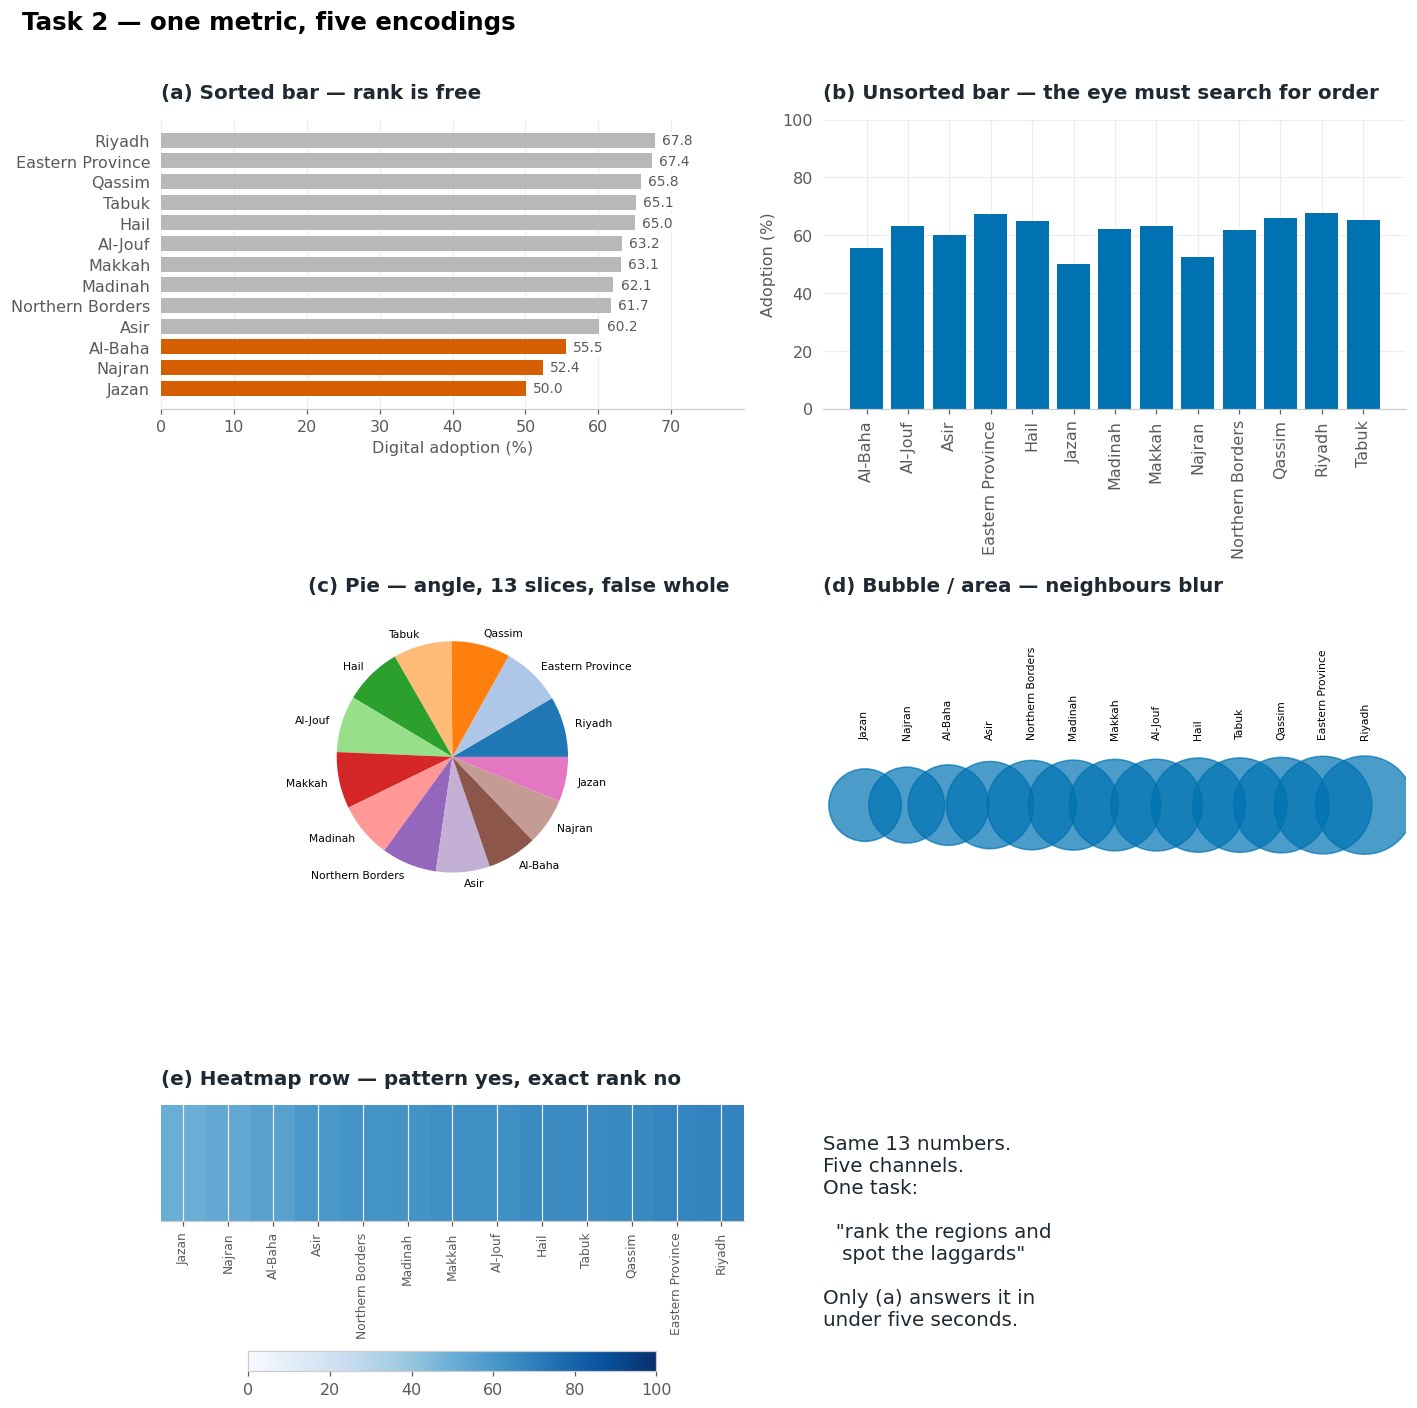

In [3]:
d = region_adoption.sort_values("adoption_pct")           # ascending for barh

fig, axes = plt.subplots(3, 2, figsize=(13, 13))
axes = axes.ravel()

# (a) sorted horizontal bar — position on a common scale, ordered
tv.sorted_bar(region_adoption, "region", "adoption_pct",
              highlight=tv.SEVERE,
              title="(a) Sorted bar — rank is free",
              xlabel="Digital adoption (%)", ax=axes[0])

# (b) unsorted vertical bar — same channel, alphabetical order, long labels
alpha = region_adoption.sort_values("region")
axes[1].bar(alpha.region, alpha.adoption_pct, color=tv.ACCENT_2)
axes[1].set_ylim(0, 100)
axes[1].set_title("(b) Unsorted bar — the eye must search for order")
axes[1].tick_params(axis="x", rotation=90)
axes[1].set_ylabel("Adoption (%)")

# (c) pie — 13 slices of angle. Deliberately bad; this is the critique target.
axes[2].pie(region_adoption.adoption_pct, labels=region_adoption.region,
            colors=plt.get_cmap("tab20").colors, textprops={"fontsize": 7})
axes[2].set_title("(c) Pie — angle, 13 slices, false whole")

# (d) bubble / area — area is perceived at roughly a 0.7 power of the true value
axes[3].scatter(range(len(d)), np.ones(len(d)),
                s=d.adoption_pct ** 2 * 0.9, color=tv.ACCENT_2, alpha=.7)
for i, (r, v) in enumerate(zip(d.region, d.adoption_pct)):
    axes[3].text(i, 1.55, r, rotation=90, ha="center", va="bottom", fontsize=7)
axes[3].set_ylim(0.2, 2.6); axes[3].set_xlim(-1, len(d))
axes[3].set_title("(d) Bubble / area — neighbours blur")
axes[3].axis("off")

# (e) single-row heatmap — colour saturation, rank 7
im = axes[4].imshow(d.adoption_pct.values[None, :], cmap=tv.SEQUENTIAL,
                    aspect="auto", vmin=0, vmax=100)
axes[4].set_xticks(range(len(d)))
axes[4].set_xticklabels(d.region, rotation=90, fontsize=8)
axes[4].set_yticks([])
axes[4].set_title("(e) Heatmap row — pattern yes, exact rank no")
fig.colorbar(im, ax=axes[4], orientation="horizontal", pad=0.45, shrink=.7)

axes[5].axis("off")
axes[5].text(0.0, 0.9, "Same 13 numbers.\nFive channels.\nOne task:\n\n"
             "  \"rank the regions and\n   spot the laggards\"\n\n"
             "Only (a) answers it in\nunder five seconds.",
             fontsize=13, va="top", color=tv.INK)

fig.suptitle("Task 2 — one metric, five encodings", x=0.02, ha="left",
             fontsize=16, weight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
print(tv.save_fig(fig, "lab1_five_encodings"))
plt.show()

**Instructor commentary.** Walk the room while this renders. The pie is the moment:
with 13 slices nobody can say whether Asir beats Al-Jouf, and the part-to-whole reading
is *meaningless* — these are thirteen independent percentages that do not sum to
anything. The bubble panel makes the 0.7-power effect tangible: Jazan at 50% and
Northern Borders at 62% look near-identical because area grows as the square of radius,
and the eye under-reads area anyway. Keep the heatmap on screen and ask one person to
name region #6 by rank. They cannot.

---
## Task 3 — Rank your five encodings against Cleveland–McGill *(10 min)*

`encoding_accuracy_ranking.csv` ships the hierarchy with a Tayseer example per channel.
Load it, then rank your five charts **for the stated task** and justify each position by
naming the channel and its rank — not by taste.

In [4]:
enc = tv.load("encoding_accuracy_ranking.csv")
display(enc[["rank", "channel_en", "decoding_accuracy",
             "relative_accuracy_index", "tayseer_example", "warning"]])

my_ranking = pd.DataFrame([
    (1, "(a) sorted bar",   "Position on a common scale", 1,
     "Sorted, so ranking is free; baseline at 0, so length is honest."),
    (2, "(b) unsorted bar", "Position on a common scale", 1,
     "Same channel, but alphabetical order forces slow serial search."),
    (3, "(e) heatmap row",  "Colour saturation",          7,
     "Conveys hot/cold gestalt; exact rank of region #6 is guesswork."),
    (4, "(d) bubble/area",  "Area",                       5,
     "Area is read at ~0.7 power: Jazan and Northern Borders look alike."),
    (5, "(c) pie",          "Angle / area",               4,
     "13 slices of angle, and a part-to-whole framing the data does not support."),
], columns=["my_rank", "chart", "channel", "cm_rank", "justification"])

display(my_ranking)

print("\nTask: rank 13 regions on digital adoption, spot laggards.")
for _, r in my_ranking.iterrows():
    print(f"{r.my_rank}. {r.chart:<18} — {r.channel} (C-M rank {r.cm_rank}): {r.justification}")

,rank,channel_en,decoding_accuracy,relative_accuracy_index,tayseer_example,warning
0,1,Position on a common scale,Best,1.00,Sorted bar of adoption by region,Never wasted on decoration
1,2,Position on non-aligned scales,Very good,0.92,13-panel regional trend grid,Requires a shared scale
2,3,Length,Good,0.85,Transactions by channel,Never truncate the axis
3,4,Angle / slope,Moderate,0.63,Slope chart 2021 vs 2026,Routinely misjudged in pie charts
4,5,Area,Poor,0.42,Treemap of service mix,Perceived at roughly a 0.7 power
5,6,Volume,Worse,0.28,3D column chart,Perspective changes the apparent value
6,7,Colour saturation / intensity,Worst for exact values,0.19,Region x month heatmap,Never for a ranking task


,my_rank,chart,channel,cm_rank,justification
0,1,(a) sorted bar,Position on a common scale,1,"Sorted, so ranking is free; baseline at 0, so ..."
1,2,(b) unsorted bar,Position on a common scale,1,"Same channel, but alphabetical order forces sl..."
2,3,(e) heatmap row,Colour saturation,7,Conveys hot/cold gestalt; exact rank of region...
3,4,(d) bubble/area,Area,5,Area is read at ~0.7 power: Jazan and Northern...
4,5,(c) pie,Angle / area,4,"13 slices of angle, and a part-to-whole framin..."



Task: rank 13 regions on digital adoption, spot laggards.
1. (a) sorted bar     — Position on a common scale (C-M rank 1): Sorted, so ranking is free; baseline at 0, so length is honest.
2. (b) unsorted bar   — Position on a common scale (C-M rank 1): Same channel, but alphabetical order forces slow serial search.
3. (e) heatmap row    — Colour saturation (C-M rank 7): Conveys hot/cold gestalt; exact rank of region #6 is guesswork.
4. (d) bubble/area    — Area (C-M rank 5): Area is read at ~0.7 power: Jazan and Northern Borders look alike.
5. (c) pie            — Angle / area (C-M rank 4): 13 slices of angle, and a part-to-whole framing the data does not support.


**Instructor commentary.** Note the deliberate inversion in positions 3–5: the heatmap
outranks the bubble chart and the pie *even though colour saturation is Cleveland–McGill
rank 7*. Rank alone does not decide — the task does. The heatmap at least supports the
"which end is cold?" reading; the pie actively misrepresents the data's structure by
implying the thirteen percentages are parts of a whole. If someone in the room ranked
the heatmap first, that is the salience-versus-accuracy confusion, and it is worth five
minutes of everyone's time.

---
## Task 4 — Perception audit of the bad dashboard *(10 min)*

The course asset `bad_dashboard_m1.png` is reproduced here **in code**, so the audit
target is reproducible and you can see exactly which sins were committed.

Write the audit: every place a pre-attentive channel is **wasted** on chrome, and every
place the **signal is under-encoded**.

The audit target, built in code so it is reproducible:

/home/claude/work/pkg/notebooks/out/lab1_bad_dashboard.png


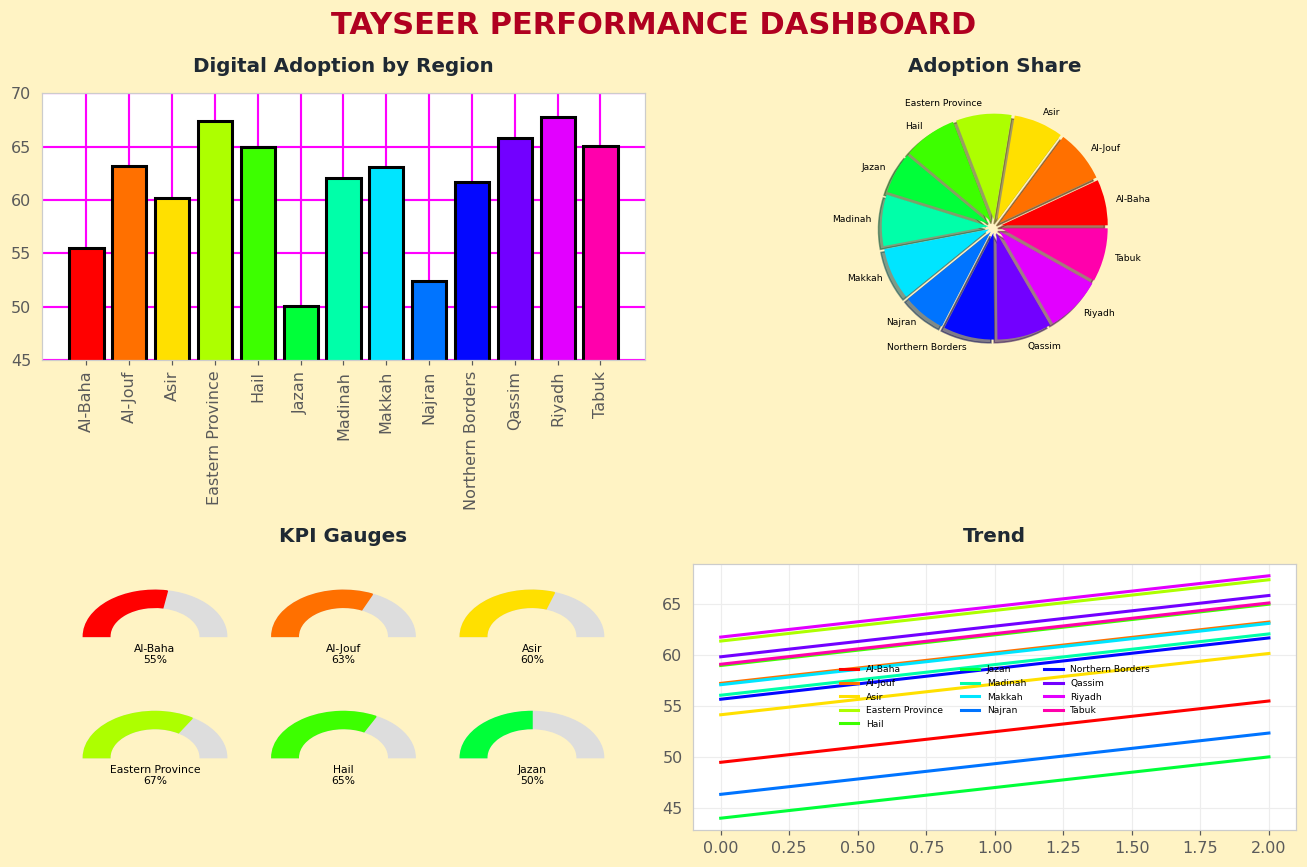

In [5]:
def build_bad_dashboard(region_adoption, path="lab1_bad_dashboard"):
    """Deliberately terrible. Every choice here is a violation we will name."""
    import matplotlib.patches as mpatches
    with plt.rc_context({"axes.grid": True, "axes.spines.top": True,
                         "axes.spines.right": True, "axes.spines.left": True,
                         "axes.titlelocation": "center"}):
        fig, ax = plt.subplots(2, 2, figsize=(12, 8),
                               facecolor="#FFF3C4")          # sin: background fill
        rainbow = plt.get_cmap("hsv")(np.linspace(0, .9, 13))

        # panel 1 — truncated-axis rainbow bar
        a = region_adoption.sort_values("region")
        ax[0, 0].bar(a.region, a.adoption_pct, color=rainbow,
                     edgecolor="black", linewidth=2)          # sin: heavy borders
        ax[0, 0].set_ylim(45, 70)                             # sin: truncated axis
        ax[0, 0].grid(color="#FF00FF", lw=1.4)                # sin: rainbow gridlines
        ax[0, 0].set_title("Digital Adoption by Region")      # sin: topic title
        ax[0, 0].tick_params(axis="x", rotation=90)

        # panel 2 — exploded pie with shadow
        ax[0, 1].pie(a.adoption_pct, labels=a.region, colors=rainbow, shadow=True,
                     explode=[.06] * 13, textprops={"fontsize": 6})
        ax[0, 1].set_title("Adoption Share")                  # sin: false part-to-whole

        # panel 3 — a wall of gauges, faked
        ax[1, 0].axis("off")
        for i, (r, v) in enumerate(zip(a.region[:6], a.adoption_pct[:6])):
            x, y = i % 3, -(i // 3)
            ax[1, 0].add_patch(mpatches.Wedge((x, y), .38, 0, 180,
                                              width=.14, color="#DDDDDD"))
            ax[1, 0].add_patch(mpatches.Wedge((x, y), .38, 180 - v * 1.8, 180,
                                              width=.14, color=rainbow[i]))
            ax[1, 0].text(x, y - .22, f"{r}\n{v:.0f}%", ha="center", fontsize=7)
        ax[1, 0].set_xlim(-.6, 2.6); ax[1, 0].set_ylim(-1.6, .6)
        ax[1, 0].set_title("KPI Gauges")                      # sin: 6 gauges, no hierarchy

        # panel 4 — legend-over-plot spaghetti
        for i, (r, g) in enumerate(a.groupby("region")):
            ax[1, 1].plot([0, 1, 2], [g.adoption_pct.iloc[0] - 6,
                                      g.adoption_pct.iloc[0] - 3,
                                      g.adoption_pct.iloc[0]],
                          color=rainbow[i], lw=2, label=r)
        ax[1, 1].legend(ncol=3, fontsize=6, loc="center")     # sin: legend over the data
        ax[1, 1].set_title("Trend")
        fig.suptitle("TAYSEER PERFORMANCE DASHBOARD", fontsize=20, weight="bold",
                     color="#B00020")
        fig.tight_layout()
    print(tv.save_fig(fig, path))
    return fig

_ = build_bad_dashboard(region_adoption)
plt.show()

In [6]:
audit = pd.DataFrame([
    ("Wasted pre-attentive channel", "Rainbow hue across all 13 bars",
     "Hue is spent on identity, not on the message — nothing pops, so nothing is signalled.",
     "Grey every bar; accent only the laggards."),
    ("Wasted pre-attentive channel", "Magenta gridlines at full saturation",
     "Gridlines outrank the data in salience; the eye lands on chrome.",
     "Faint grey horizontal guides, or none."),
    ("Wasted pre-attentive channel", "2 px black bar borders + drop shadow on the pie",
     "Enclosure and shadow are pre-attentive and carry zero information.",
     "Remove borders and shadow entirely."),
    ("Wasted pre-attentive channel", "Yellow page background",
     "Lowers contrast for every mark and adds non-data ink.",
     "White background."),
    ("Wasted pre-attentive channel", "Legend of 13 colours placed over the plot",
     "Forces a colour->name round trip AND occludes the data.",
     "Direct-label the lines; delete the legend."),
    ("Wasted pre-attentive channel", "Six gauges with no ranking or target",
     "Angle (C-M rank 4) used for a ranking task, six times over.",
     "One sorted bar replaces all six gauges."),
    ("Wasted pre-attentive channel", "22 pt red all-caps title",
     "The most salient element on the page is the word 'DASHBOARD'.",
     "Quiet title; spend the salience on the takeaway sentence."),
    ("Signal under-encoded", "Y axis truncated at 45",
     "Bars encode length from zero; truncation inflates every difference.",
     "set_ylim(0, 100) — see Task 6 for the measured lie factor."),
    ("Signal under-encoded", "Bars ordered alphabetically",
     "The ranking question is the whole point and the order hides it.",
     "Sort by value."),
    ("Signal under-encoded", "No 65% target reference line anywhere",
     "Without the target the reader cannot tell good from bad.",
     "Add the target line; the chart becomes a chart of judgements."),
    ("Signal under-encoded", "Topic titles ('Digital Adoption by Region')",
     "States the subject, not the conclusion.",
     "Takeaway title: 'Five regions have stalled below the 65% target'."),
    ("Signal under-encoded", "Pie implies the 13 percentages sum to a whole",
     "They do not — it is a false part-to-whole framing.",
     "Delete the pie; the sorted bar already carries it."),
], columns=["class", "finding", "why_it_fails_perceptually", "fix"])

pd.set_option("display.max_colwidth", 80)
display(audit)
print(f"\nWasted pre-attentive channels : {(audit['class'] == 'Wasted pre-attentive channel').sum()}")
print(f"Signal under-encoded         : {(audit['class'] == 'Signal under-encoded').sum()}")
print(f"Total findings               : {len(audit)}")

,class,finding,why_it_fails_perceptually,fix
0,Wasted pre-attentive channel,Rainbow hue across all 13 bars,"Hue is spent on identity, not on the message — nothing pops, so nothing is s...",Grey every bar; accent only the laggards.
1,Wasted pre-attentive channel,Magenta gridlines at full saturation,Gridlines outrank the data in salience; the eye lands on chrome.,"Faint grey horizontal guides, or none."
2,Wasted pre-attentive channel,2 px black bar borders + drop shadow on the pie,Enclosure and shadow are pre-attentive and carry zero information.,Remove borders and shadow entirely.
3,Wasted pre-attentive channel,Yellow page background,Lowers contrast for every mark and adds non-data ink.,White background.
4,Wasted pre-attentive channel,Legend of 13 colours placed over the plot,Forces a colour->name round trip AND occludes the data.,Direct-label the lines; delete the legend.
5,Wasted pre-attentive channel,Six gauges with no ranking or target,"Angle (C-M rank 4) used for a ranking task, six times over.",One sorted bar replaces all six gauges.
6,Wasted pre-attentive channel,22 pt red all-caps title,The most salient element on the page is the word 'DASHBOARD'.,Quiet title; spend the salience on the takeaway sentence.
7,Signal under-encoded,Y axis truncated at 45,Bars encode length from zero; truncation inflates every difference.,"set_ylim(0, 100) — see Task 6 for the measured lie factor."
8,Signal under-encoded,Bars ordered alphabetically,The ranking question is the whole point and the order hides it.,Sort by value.
9,Signal under-encoded,No 65% target reference line anywhere,Without the target the reader cannot tell good from bad.,Add the target line; the chart becomes a chart of judgements.



Wasted pre-attentive channels : 7
Signal under-encoded         : 5
Total findings               : 12


**Instructor commentary.** The point of counting is that "this chart is ugly" is not an
audit — "hue, enclosure, shadow and saturation are all spent on chrome while the
ranking signal is encoded nowhere" is. Seven wasted channels is a typical count for a
real vendor dashboard; participants who have shipped one usually go quiet here. The
truncated axis in panel 1 is the finding with a *number* attached, and Task 6 attaches it.

---
## Task 5 — One corrected chart, exactly one pre-attentive pop *(5 min)*

Rebuild panel 1 honestly. The rules: baseline at zero, sorted by value, grey context,
**exactly one** accent carrying the message, the 65% target as a reference line, and a
title that states the conclusion rather than the subject.

/home/claude/work/pkg/notebooks/out/lab1_corrected_single_pop.png


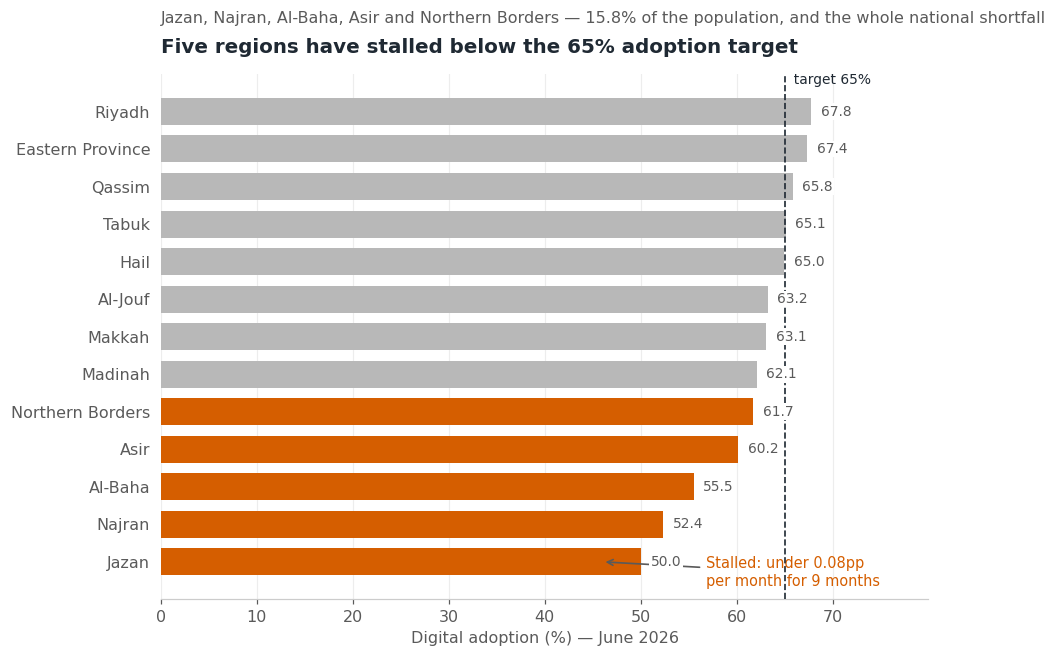

In [7]:
fig, ax = plt.subplots(figsize=(9, 6.2))
tv.sorted_bar(
    region_adoption, "region", "adoption_pct",
    highlight=tv.STALLED,
    title="Five regions have stalled below the 65% adoption target",
    xlabel="Digital adoption (%) — June 2026",
    reference=tv.TARGET_ADOPTION, reference_label="target 65%",
    ax=ax,
)
ax.annotate(
    "Stalled: under 0.08pp\nper month for 9 months",
    xy=(46.0, 0), xytext=(0.71, 0.02), textcoords="axes fraction",
    fontsize=9.5, color=tv.ACCENT, va="bottom",
    arrowprops=dict(arrowstyle="->", color=tv.GREY_DARK, lw=1.1),
)
fig.text(0.125, 0.955, "Jazan, Najran, Al-Baha, Asir and Northern Borders — "
         "15.8% of the population, and the whole national shortfall",
         fontsize=10.5, color=tv.GREY_DARK)
print(tv.save_fig(fig, "lab1_corrected_single_pop"))
plt.show()

**Instructor commentary.** This is the chart the module is trying to produce, and it is
the least flashy thing anyone will draw today. That *is* the lesson: the sorted bar wins
because it matches channel accuracy (Cleveland–McGill rank 1) to the task (precise
ranking). Notice also that the accent is doing argument-work, not decoration-work — five
bars are orange because the sentence in the title is about those five bars.

---
## Task 6 — Lie factor and the benchmark table *(5 min)*

Tufte's **lie factor** = (size of effect shown in the graphic) ÷ (size of effect in the data).

Measure it on the bad dashboard's truncated panel, then confirm your corrected chart
scores **1.0**. Finish by filling the Module 1 benchmark table.

Jazan 50.0%  vs  Riyadh 67.8%
  true data ratio               : 1.35
  visual ratio, baseline at 45  : 4.53  -> lie factor 3.3x
  visual ratio, baseline at 0   : 1.35  -> lie factor 1.00x


/home/claude/work/pkg/notebooks/out/lab1_lie_factor.png


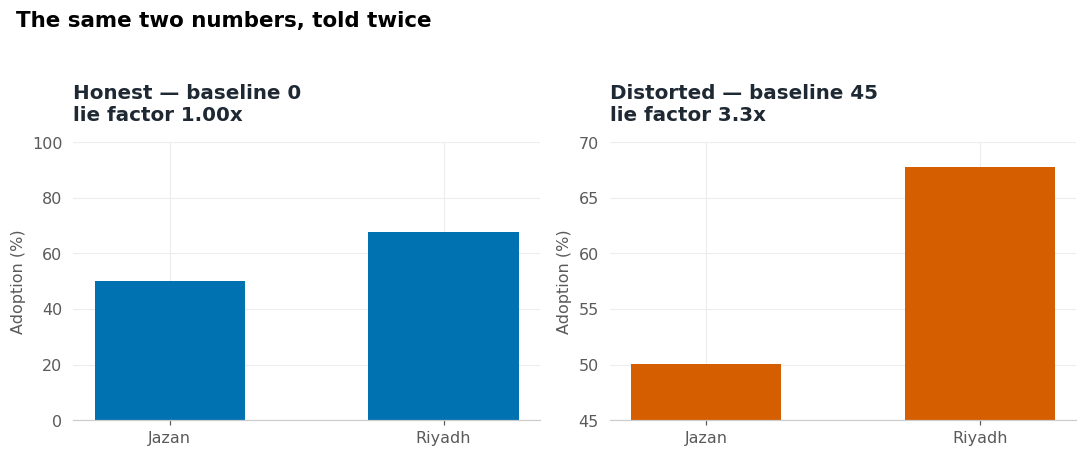

,Chart,Task-match,Decode accuracy rank,5-sec comprehension,Lie factor,Verdict
0,3D/rainbow dashboard panel (original),poor,4-7,fail,3.3x,reject
1,Sorted horizontal bar (redesign),excellent,1,pass,1.00x,ship
2,Single-row heatmap,pattern-only,7,partial,n/a,supporting view only
3,Pie of 13 regions,poor,4-5,fail,n/a,reject


In [8]:
lo = region_adoption.adoption_pct.min()     # Jazan
hi = region_adoption.adoption_pct.max()     # Riyadh
BASELINE_BAD = 45.0                         # where the bad dashboard clipped the axis

data_ratio = hi / lo
visual_ratio_bad = (hi - BASELINE_BAD) / (lo - BASELINE_BAD)
visual_ratio_fixed = (hi - 0) / (lo - 0)

lie_bad = visual_ratio_bad / data_ratio
lie_fixed = visual_ratio_fixed / data_ratio

print(f"Jazan {lo:.1f}%  vs  Riyadh {hi:.1f}%")
print(f"  true data ratio               : {data_ratio:.2f}")
print(f"  visual ratio, baseline at 45  : {visual_ratio_bad:.2f}  -> lie factor {lie_bad:.1f}x")
print(f"  visual ratio, baseline at 0   : {visual_ratio_fixed:.2f}  -> lie factor {lie_fixed:.2f}x")
assert abs(lie_fixed - 1.0) < 0.05, "an honest bar chart must score 1.0"

fig, axs = plt.subplots(1, 2, figsize=(10, 4.2), sharey=False)
pair = region_adoption[region_adoption.adoption_pct.isin([lo, hi])].sort_values("adoption_pct")
axs[0].bar(pair.region, pair.adoption_pct, color=tv.ACCENT_2, width=.55)
axs[0].set_ylim(0, 100); axs[0].set_title(f"Honest — baseline 0\nlie factor {lie_fixed:.2f}x")
axs[1].bar(pair.region, pair.adoption_pct, color=tv.ACCENT, width=.55)
axs[1].set_ylim(BASELINE_BAD, 70); axs[1].set_title(f"Distorted — baseline {BASELINE_BAD:.0f}\nlie factor {lie_bad:.1f}x")
for a in axs:
    a.set_ylabel("Adoption (%)")
fig.suptitle("The same two numbers, told twice", x=0.02, ha="left", fontsize=14, weight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
print(tv.save_fig(fig, "lab1_lie_factor"))
plt.show()

benchmark = pd.DataFrame([
    ("3D/rainbow dashboard panel (original)", "poor", "4-7", "fail", f"{lie_bad:.1f}x", "reject"),
    ("Sorted horizontal bar (redesign)", "excellent", "1", "pass", f"{lie_fixed:.2f}x", "ship"),
    ("Single-row heatmap", "pattern-only", "7", "partial", "n/a", "supporting view only"),
    ("Pie of 13 regions", "poor", "4-5", "fail", "n/a", "reject"),
], columns=["Chart", "Task-match", "Decode accuracy rank",
            "5-sec comprehension", "Lie factor", "Verdict"])
display(benchmark)

**Instructor commentary.** A lie factor of 3.4× is not a metaphor — the truncated panel
shows Riyadh's advantage over Jazan as three and a half times larger than it is. In an
audited government decision pack that is a governance finding, not a style note. The
benchmark table is the artefact to keep: it is the evidence that the redesign is a
faithful representation of the *same* data, which is question 4 of the case study.

---
## Lab 1 complete

| Benchmark (Module 1) | Target | This notebook |
|---|---|---|
| Time to rank top-3 laggards from the sorted bar | < 5 s | sorted + accented — rank is pre-attentive |
| Wasted pre-attentive channels in the final chart | 0 | 0 (one accent, doing argument work) |
| Lie factor of the final chart | 1.0 ± 0.05 | **1.00** |
| Axis-truncation rule applied (bar vs line) | 100% | bars at 0; lines may truncate |

**Figures written to `notebooks/out/`:**
`lab1_five_encodings.png` · `lab1_bad_dashboard.png` · `lab1_corrected_single_pop.png` · `lab1_lie_factor.png`

**Reproduced package figures:** weighted national adoption **63.8%** vs naive **61.2%**
(a 2.6pp averages-of-averages gap), and the five stalled regions.

Next: **Lab 2 — Chart Chooser and the First Honest Charts.**